# Lineage tree plotting and region-properties re-computation

This example demonstrates two utilities of `tracksdata`:

1. [`plot_lineage_tree`](https://royerlab.github.io/tracksdata/) — plot a tracking graph as a
   lineage tree in matplotlib, with node attributes bound to marker color and size, optional
   time-window selection, and exact time positions (e.g. timestamps).
2. [`RegionPropsAttrs`](https://royerlab.github.io/tracksdata/) — (re-)compute scikit-image
   region properties for *existing* nodes from their stored masks and a given intensity image,
   without rebuilding the graph.

Requirements: `pip install "tracksdata[plot]"` (installs matplotlib).

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import skimage.draw

import tracksdata as td
from tracksdata.functional import plot_lineage_tree

td.options.set_options(show_progress=False)
rng = np.random.default_rng(42)

## 1. Simulate a dividing-cell timelapse

We simulate three founder cells performing a random walk in 2D. Some of them divide,
and every cell slowly gets brighter over time. The simulation produces:

- `labels`: a `(t, y, x)` label image used to build the graph, and
- `intensity`: a separate `(t, y, x)` intensity channel that we will only use **later**,
  to re-compute intensity features on the already-built graph.

In [2]:
N_FRAMES, SHAPE = 20, (220, 220)


def make_cell(pos, radius, brightness, divisions=()):
    return {
        "pos": np.asarray(pos, dtype=float),
        "radius": radius,
        "brightness": brightness,
        # frames at which this cell (and then one of its children) will divide
        "divisions": tuple(divisions),
    }


cells = [
    make_cell((60, 50), 10, 0.50, divisions=(6, 13)),
    make_cell((160, 70), 11, 0.80, divisions=(10,)),
    make_cell((110, 180), 9, 0.65),
]

labels = np.zeros((N_FRAMES, *SHAPE), dtype=np.uint16)
intensity = np.zeros((N_FRAMES, *SHAPE), dtype=np.float32)

for t in range(N_FRAMES):
    next_cells = []
    for cell in cells:
        cell["pos"] = cell["pos"] + rng.normal(0.0, 1.5, size=2)
        cell["brightness"] *= 1.03  # cells get brighter over time
        if cell["divisions"] and t == cell["divisions"][0]:
            axis = rng.normal(size=2)
            axis *= cell["radius"] / np.linalg.norm(axis)
            radius = max(6, round(cell["radius"] * 0.8))
            for sign, divisions in ((1, cell["divisions"][1:]), (-1, ())):
                next_cells.append(make_cell(cell["pos"] + sign * axis, radius, cell["brightness"], divisions))
        else:
            next_cells.append(cell)
    cells = next_cells
    for label, cell in enumerate(cells, start=1):
        cell["pos"] = np.clip(cell["pos"], cell["radius"] + 2, np.asarray(SHAPE) - cell["radius"] - 2)
        rr, cc = skimage.draw.disk(cell["pos"], cell["radius"], shape=SHAPE)
        labels[t, rr, cc] = label
        intensity[t, rr, cc] = cell["brightness"]
    intensity[t] += rng.normal(0.0, 0.03, SHAPE).astype(np.float32)

print("cells per frame:", [int(labels[t].max()) for t in range(N_FRAMES)])

cells per frame: [3, 3, 3, 3, 3, 3, 4, 4, 4, 4, 5, 5, 5, 6, 6, 6, 6, 6, 6, 6]


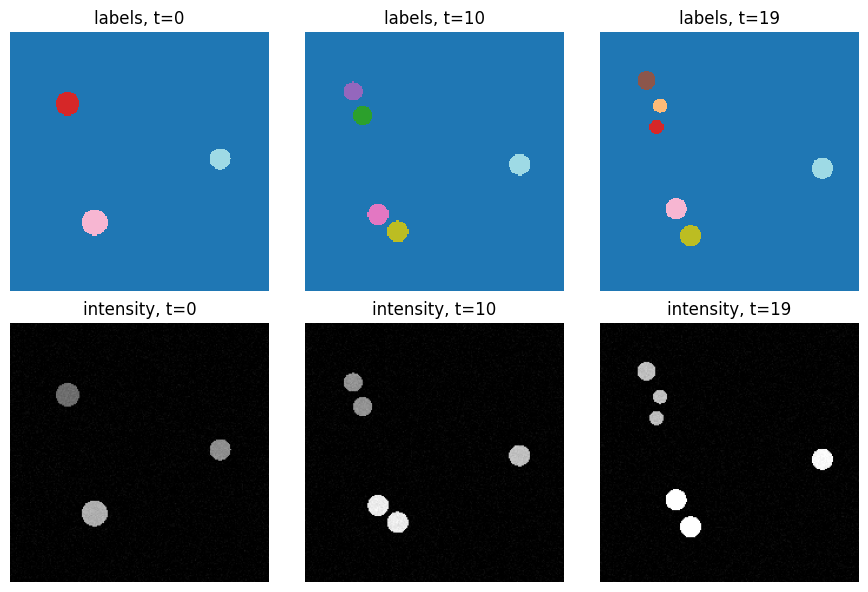

In [3]:
fig, axs = plt.subplots(2, 3, figsize=(9, 6))
for col, t in enumerate([0, 10, N_FRAMES - 1]):
    axs[0, col].imshow(labels[t], cmap="tab20", interpolation="nearest")
    axs[0, col].set_title(f"labels, t={t}")
    axs[1, col].imshow(intensity[t], cmap="gray", vmin=0, vmax=1.2)
    axs[1, col].set_title(f"intensity, t={t}")
for ax in axs.ravel():
    ax.set_axis_off()
fig.tight_layout()

## 2. Build and solve a tracking graph

The standard `tracksdata` workflow: extract nodes (with masks) from the label image,
connect candidates in consecutive frames, and solve. Note that we only request the
geometric property `area` here — no intensity information is used at this point.

In [4]:
graph = td.graph.RustWorkXGraph()

td.nodes.RegionPropsNodes(extra_properties=["area"]).add_nodes(graph, labels=labels)
td.edges.DistanceEdges(distance_threshold=30.0, n_neighbors=3).add_edges(graph)

td.solvers.NearestNeighborsSolver(
    edge_weight=td.EdgeAttr("distance"),
    max_children=2,  # allow divisions
).solve(graph)

# keep only the nodes and edges selected by the solver
solution = graph.filter(
    td.NodeAttr("solution") == True,
    td.EdgeAttr("solution") == True,
).subgraph()

print(f"{solution.num_nodes()} nodes, {solution.num_edges()} edges in the solution")

[06/11/26 19:46:27] WARNING  No nodes found for time point in range (-1 <= t < 0)            ]8;id=4829242;file:///workspace/src/tracksdata/edges/_distance_edges.py\_distance_edges.py]8;;\:]8;id=4829243;file:///workspace/src/tracksdata/edges/_distance_edges.py#318\318]8;;\

91 nodes, 88 edges in the solution


## 3. Plot the lineage tree

`plot_lineage_tree` lays the graph out as a lineage tree: nodes are drawn as points aligned
in time, all nodes of a tracklet share a coordinate on the tree axis, and parent tracklets
are centered between their children, so divisions appear as forks.

If the graph has no tracklet ids yet, they are assigned automatically (modifying the graph).

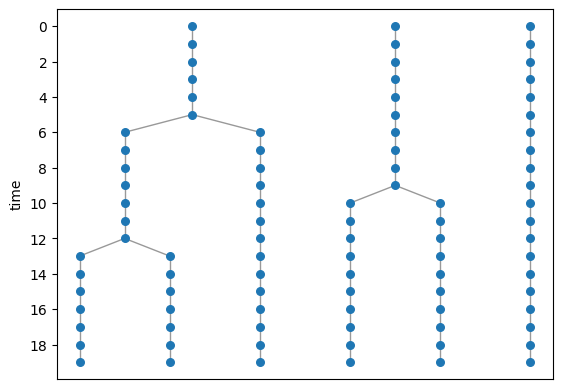

In [5]:
ax = plot_lineage_tree(solution)

## 4. Re-compute region properties from the existing masks

The nodes were created without intensity features. Instead of rebuilding the graph,
`RegionPropsAttrs` evaluates scikit-image's `regionprops` on each node's stored
[`Mask`](https://royerlab.github.io/tracksdata/) — cropped to its bounding box and combined
with the intensity image of the corresponding time point.

This is useful to add features of another channel, or to refresh properties after masks
were edited. Existing attribute values are overwritten; missing attribute keys are
registered automatically. Like `RegionPropsNodes`, it accepts property names and
custom callables.

In [6]:
td.nodes.RegionPropsAttrs(
    properties=["intensity_mean", "eccentricity"],
).add_node_attrs(solution, intensity_image=intensity)

solution.node_attrs(attr_keys=["t", "area", "intensity_mean", "eccentricity"]).head()

t,area,intensity_mean,eccentricity
i32,f64,f32,f64
0,316.0,0.515461,0.0
0,380.0,0.822809,0.103065
0,251.0,0.671207,0.20051
1,317.0,0.530767,0.129031
1,374.0,0.846975,0.216685


## 5. Bind attributes to marker color and size

Any numeric node attribute can be bound to the marker colors (`color_attr`, with a
customizable `cmap` and `color_norm`) and sizes (`size_attr`, mapped linearly onto
`size_range`, optionally normalized with `size_norm`).

The brightening of the cells over time is now clearly visible along the tree.

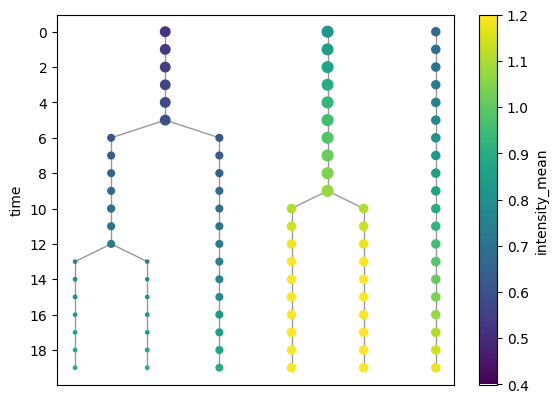

In [7]:
ax = plot_lineage_tree(
    solution,
    color_attr="intensity_mean",
    cmap="viridis",
    color_norm=(0.4, 1.2),
    size_attr="area",
    size_range=(5.0, 60.0),
)
ax.figure.colorbar(ax.collections[-1], ax=ax, label="intensity_mean");

## 6. Selecting time points and exact time positions

The set of displayed time points can be restricted in two ways:

- `time_range=(start, end)` keeps a contiguous time window (inclusive).
- `time_points=[...]` keeps an arbitrary, possibly non-contiguous subset of time points
  (e.g. every other frame). Edges are only drawn between two displayed nodes.

In both cases `time_positions` can place the time points at exact positions, e.g. acquisition
timestamps — either a mapping `{time_point: position}` or a sequence indexed by time point.
Without it, the displayed time points are evenly separated and labeled with their values.

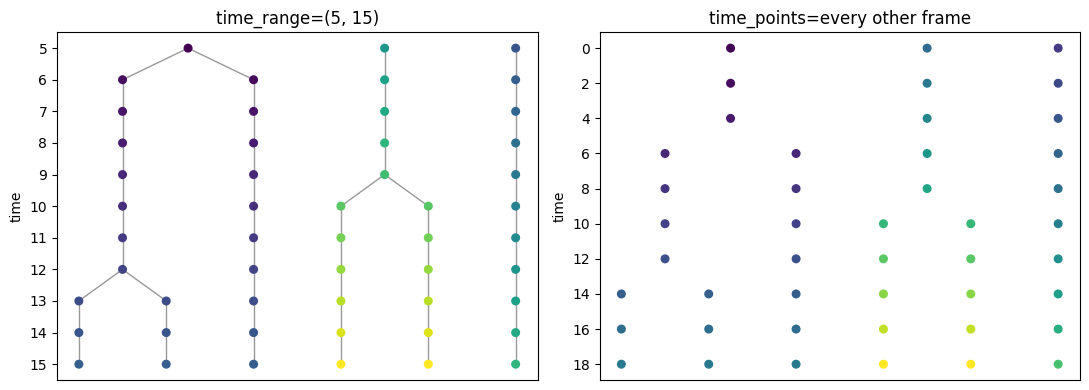

In [8]:
fig, (ax_left, ax_right) = plt.subplots(1, 2, figsize=(11, 4))

# contiguous window around the divisions
plot_lineage_tree(solution, ax=ax_left, time_range=(5, 15), color_attr="intensity_mean")
ax_left.set_title("time_range=(5, 15)")

# every other frame: a non-contiguous subset
plot_lineage_tree(solution, ax=ax_right, time_points=list(range(0, N_FRAMES, 2)), color_attr="intensity_mean")
ax_right.set_title("time_points=every other frame")
fig.tight_layout()

## 7. Marker borders and orientation

Any extra `Axes.scatter` argument can be passed via `scatter_kwargs`, including `edgecolors`
and `linewidths` to style the marker borders — independent of the colormap used for the faces.
Edge line styling goes through `line_kwargs`. `orientation="horizontal"` draws time along the
x-axis instead, here with minute timestamps and an acquisition gap between frames 12 and 13.

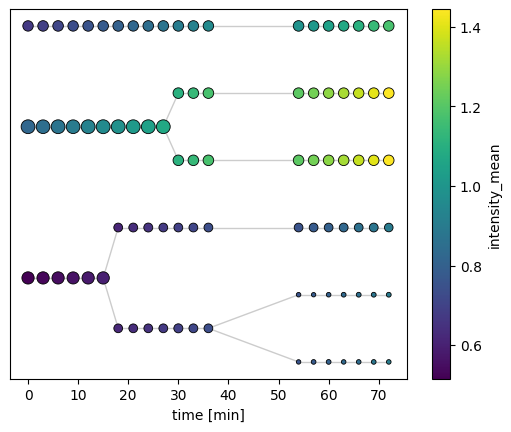

In [9]:
# one frame every 3 minutes, with an acquisition gap between frames 12 and 13
timestamps = {t: 3.0 * t if t <= 12 else 3.0 * t + 15.0 for t in range(N_FRAMES)}

ax = plot_lineage_tree(
    solution,
    orientation="horizontal",
    time_positions=timestamps,
    color_attr="intensity_mean",
    size_attr="area",
    scatter_kwargs={"edgecolors": "black", "linewidths": 0.6},
    line_kwargs={"color": "0.8"},
)
ax.set_xlabel("time [min]")
ax.figure.colorbar(ax.collections[-1], ax=ax, label="intensity_mean");

## See also

- `tracksdata.functional.plot_lineage_tree` — all plotting options
  (`scatter_kwargs` / `line_kwargs` forward to the underlying matplotlib artists).
- `tracksdata.nodes.RegionPropsAttrs` — re-computing region properties; use `mask_key`
  to select a different mask attribute and `spacing` for physical pixel sizes.
- `tracksdata.functional.to_napari_format` — interactive visualization in napari.